# HyPhy Omega Distribution Plots

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

In [3]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None, 'display.max_rows', 50)

# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)
from omega_plots import (
    plot_omega_distributions,
    plot_omega_single_gene
)

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data/")
figures = os.path.join(scripts, "..", "figures/")
hyphy_results = os.path.join(scripts, "..", "results/hyphy_results_cache/")

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(str(hyphy_results + "relax_results.pkl"))

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_results.pkl"))

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_rev_results.pkl"))

Filter out extremely large omega values from the results (arbitrary threshold of 10,000)

In [6]:
relax_result_fltrd = relax_result.filter_omega(10000)
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)

In [7]:
relax_df_fltrd = relax_result_fltrd.results_df
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df

## Omega plots

(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

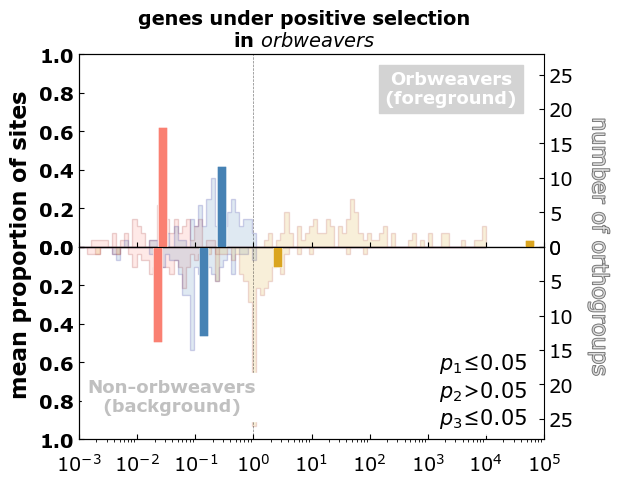

In [26]:
x=busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit']
result='busted'
top_title = 'Orbweavers\n(foreground)'
bottom_title = 'Non-orbweavers\n(background)'

%autoreload 2
plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="genes under positive selection\nin " + r"$\it{orbweavers}$",
    filename=str(figures + 'figure_4/busted_ph_omega_dist.png'),
    transparent=True
    )

(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

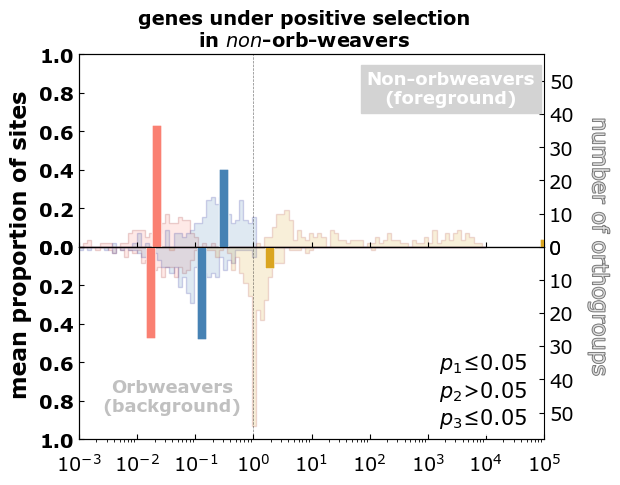

In [29]:
x=busted_ph_rev_df_fltrd[busted_ph_rev_df_fltrd['result']=='hit']
result='busted'
top_title = 'Non-orbweavers\n(foreground)'
bottom_title = 'Orbweavers\n(background)'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="genes under positive selection\nin " + r"$\it{non}$" + "-orb-weavers",
    filename=str(figures + 'figure_4/busted_ph_rev_omega_dist.png'),
    transparent=True
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

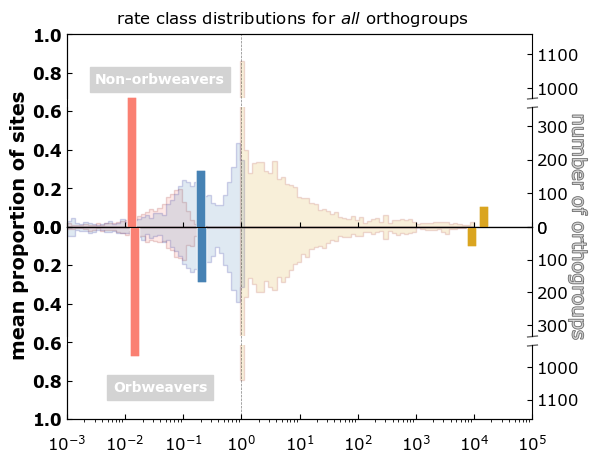

In [17]:
x=relax_df_fltrd

result='all'
top_title = 'Non-orbweavers'
bottom_title = 'Orbweavers'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="rate class distributions for " + r"$\it{all}$" + " orthogroups",
    # filename=str(figures + 'figure_2/relax_all_omega_dist.png'),
    transparent=False
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

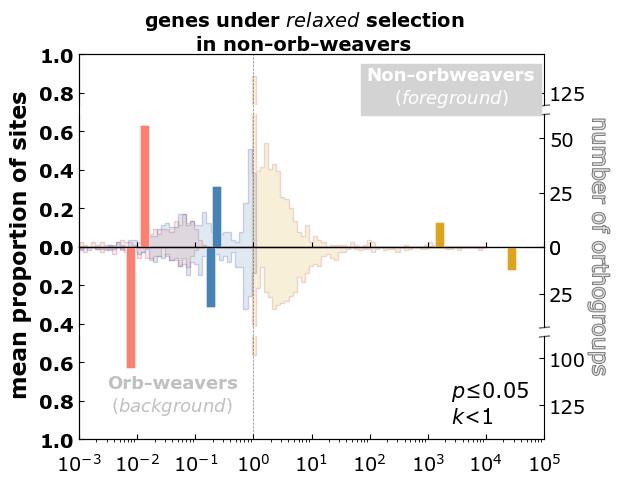

In [13]:
x=relax_df_fltrd[relax_df_fltrd['result']=='relaxed']
result='relaxed'
top_title = 'Non-orbweavers\n' + r"$\it{(foreground)}$"
bottom_title = 'Orb-weavers\n' + r"$\it{(background)}$"

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title,
    suptitle="genes under " + r"$\it{relaxed}$" + " selection\nin non-orb-weavers", 
    filename=str(figures + 'figure_3/relax_relaxed_omega_dist.png'),
    transparent=True
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

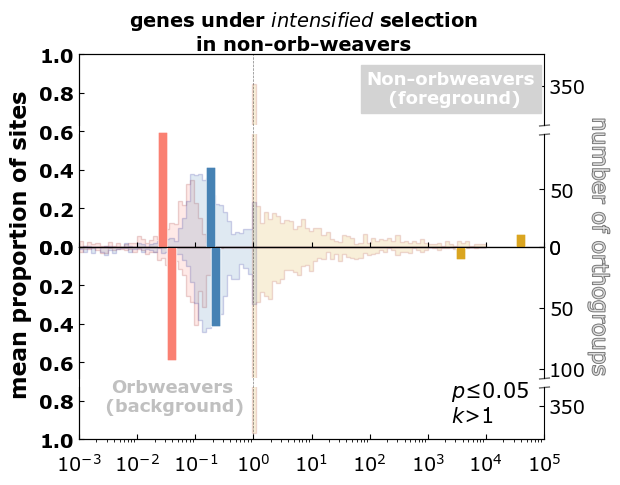

In [20]:
x=relax_df_fltrd[relax_df_fltrd['result']=='intensified']
result='intensified'
top_title = 'Non-orbweavers\n (foreground)'
bottom_title = 'Orbweavers\n (background)'

%autoreload 2
plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="genes under " + r"$\it{intensified}$" + " selection\nin non-orb-weavers", 
    filename=str(figures + 'figure_3/relax_intensified_omega_dist.png'),
    transparent=True
)

Plot example genes from each selection pattern

(<Figure size 550x500 with 1 Axes>, <Axes: >)

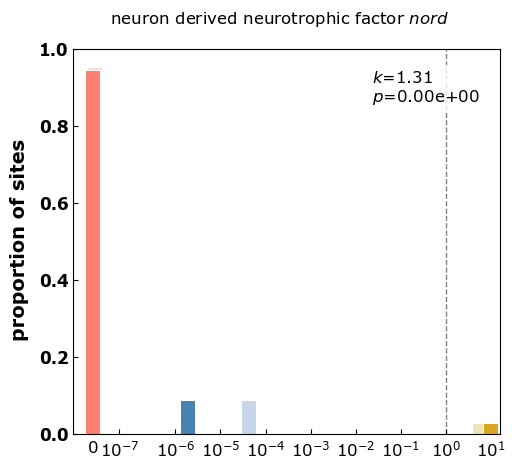

In [20]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0061683', 
    'neuron derived neurotrophic factor $\it{nord}$',  
    offset_zero=True, 
    k=True,
    # filename=str(figures + 'figure_2/relax_nord_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

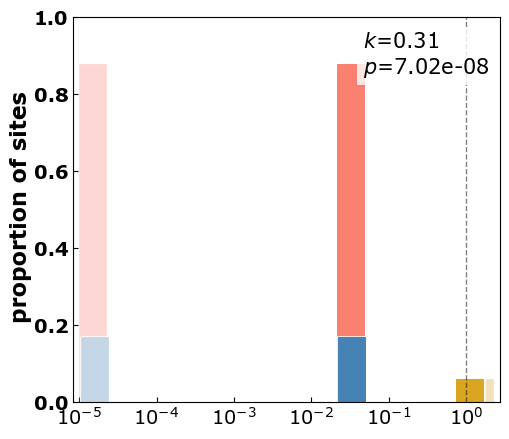

In [10]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0066983', 
    k=True,
    filename=str(figures + 'figure_3/relax_acetylcholine_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

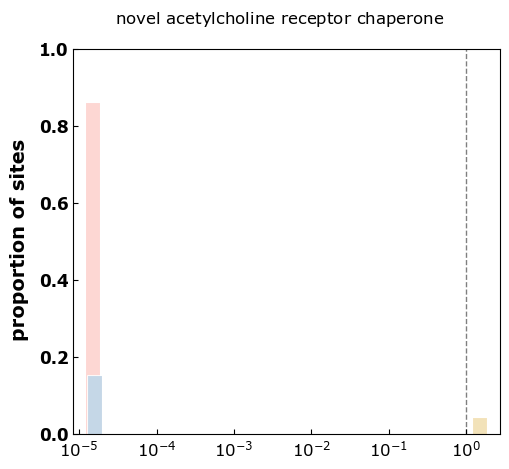

In [ ]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0066983', 
    suptitle='novel acetylcholine receptor chaperone',
    k=True,
    filename=str(figures + 'figure_3/relax_acetylcholine_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

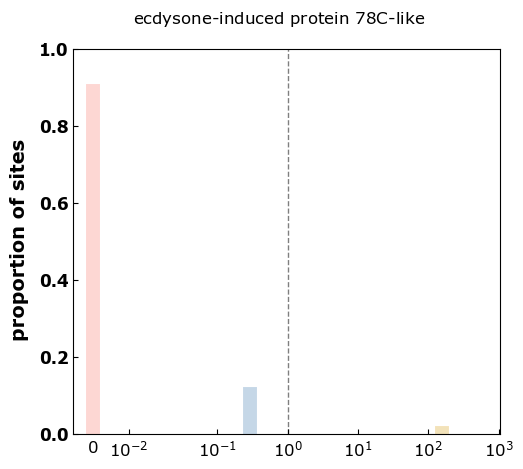

In [ ]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0048857', 
    suptitle = 'ecdysone-induced protein 78C-like', 
    k=True,
    filename=str(figures + 'figure_3/relax_ecdysone_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

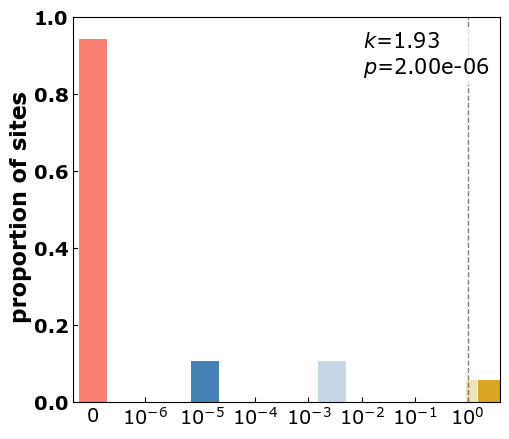

In [12]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0037767', 
    # suptitle = 'ecdysone-induced protein 78C-like', 
    offset_zero=True, 
    k=True,
    filename=str(figures + 'figure_3/relax_ecdysone_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

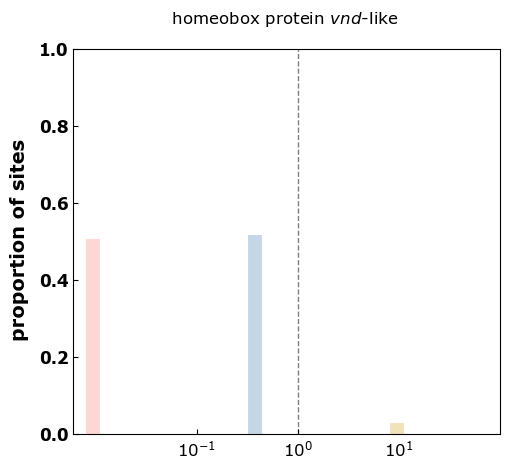

In [ ]:
plot_omega_single_gene(
    busted_ph_df_fltrd, 
    'N5.HOG0069577', 
    suptitle='  homeobox protein $\it{vnd}$-like',
    filename=str(figures + 'figure_4/busted_ph_hox_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

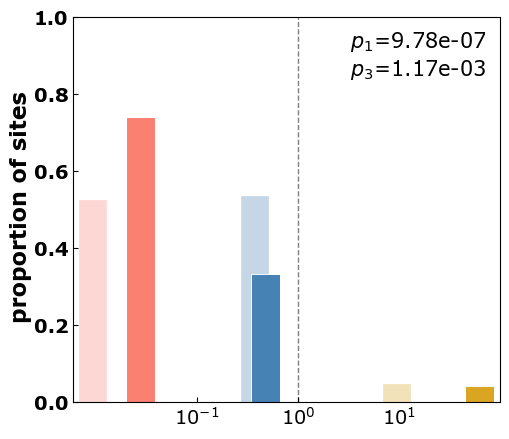

In [32]:
plot_omega_single_gene(
    busted_ph_df_fltrd, 
    'N5.HOG0069577', 
    # suptitle='  homeobox protein $\it{vnd}$-like',
    filename=str(figures + 'figure_4/busted_ph_hox_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

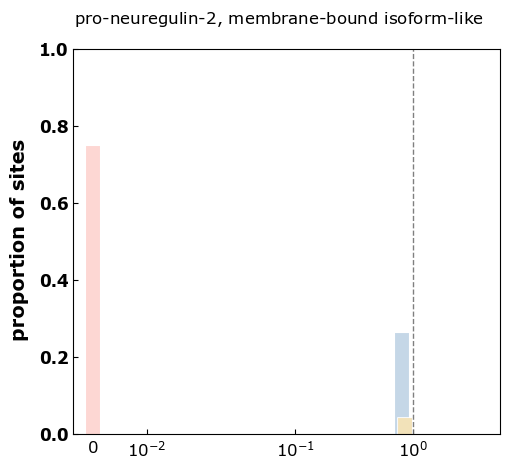

In [ ]:
plot_omega_single_gene(
    busted_ph_rev_df_fltrd, 
    'N5.HOG0028049', 
    suptitle='pro-neuregulin-2, membrane-bound isoform-like',
    filename=str(figures + 'figure_4/busted_ph_proneuregulin_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

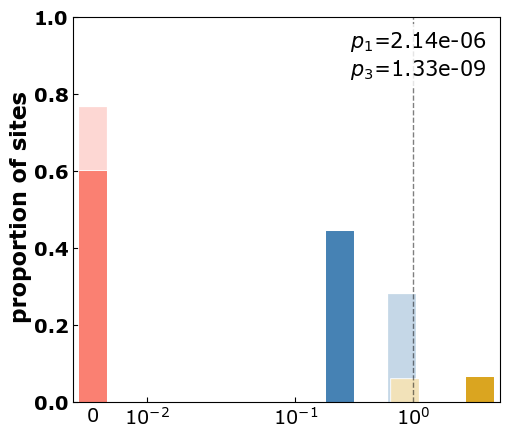

In [33]:
plot_omega_single_gene(
    busted_ph_rev_df_fltrd, 
    'N5.HOG0028049', 
    # suptitle='pro-neuregulin-2, membrane-bound isoform-like',
    filename=str(figures + 'figure_4/busted_ph_proneuregulin_omega_plot.png'),
    transparent=False
    )